# Análisis Predictivo de Ventas E-Commerce
## Objetivo
Predecir el **Profit** de transacciones de e-commerce usando Machine Learning.
Conexión a base de datos MySQL externa via pymysql, procesamiento con PySpark y modelo con Scikit-learn.

In [0]:
%pip install pymysql

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%restart_python

## Conexión a Base de Datos MySQL (Aiven)

In [0]:
import pymysql
import pandas as pd

conn = pymysql.connect(
    host="mysql-ecommerce-upao-d700.b.aivencloud.com",
    port=11749,
    user="avnadmin",
    password="REMPLAZAR_CON_SU_CONTRASEÑA_DE_AIVEN",  # <--- Ocultar aquí
    database="defaultdb",
    ssl={"ssl_mode": "REQUIRED"}
)

pdf = pd.read_sql("SELECT * FROM ecommerce_sales", conn)
conn.close()

print(f"Conexión exitosa. Filas cargadas: {len(pdf)}")
print(pdf.head())

/home/spark-118e7ba9-6cfb-4f94-ac75-25/.ipykernel/308/command-6737305000102013-539236589:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pdf = pd.read_sql("SELECT * FROM ecommerce_sales", conn)


Conexión exitosa. Filas cargadas: 3500
   id  Order Date Product Name     Category Region  Quantity  Sales  Profit
0   0  2024-12-31      Printer       Office  North         4   3640  348.93
1   1  2022-11-27        Mouse  Accessories   East         7   1197  106.53
2   2  2022-05-11       Tablet  Electronics  South         5   5865  502.73
3   3  2024-03-16        Mouse  Accessories  South         2    786  202.87
4   4  2022-09-10        Mouse  Accessories   West         1    509  103.28


In [0]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("EcommerceML").getOrCreate()
df = spark.createDataFrame(pdf)

print("Spark DataFrame creado")
df.printSchema()
df.show(5)

Spark DataFrame creado
root
 |-- id: long (nullable = true)
 |-- Order Date: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- Sales: long (nullable = true)
 |-- Profit: double (nullable = true)

+---+----------+------------+-----------+------+--------+-----+------+
| id|Order Date|Product Name|   Category|Region|Quantity|Sales|Profit|
+---+----------+------------+-----------+------+--------+-----+------+
|  0|2024-12-31|     Printer|     Office| North|       4| 3640|348.93|
|  1|2022-11-27|       Mouse|Accessories|  East|       7| 1197|106.53|
|  2|2022-05-11|      Tablet|Electronics| South|       5| 5865|502.73|
|  3|2024-03-16|       Mouse|Accessories| South|       2|  786|202.87|
|  4|2022-09-10|       Mouse|Accessories|  West|       1|  509|103.28|
+---+----------+------------+-----------+------+--------+-----+------+
only showing top 5 rows


## Exploración de Datos (EDA)

In [0]:
from pyspark.sql.functions import col, count, when

print(f"Filas: {df.count()} | Columnas: {len(df.columns)}")

df.describe().show()

df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

df.groupBy("Category").count().orderBy("count", ascending=False).show()
df.groupBy("Region").count().orderBy("count", ascending=False).show()

Filas: 3500 | Columnas: 8
+-------+------------------+----------+------------+-----------+------+------------------+----------------+------------------+
|summary|                id|Order Date|Product Name|   Category|Region|          Quantity|           Sales|            Profit|
+-------+------------------+----------+------------+-----------+------+------------------+----------------+------------------+
|  count|              3500|      3500|        3500|       3500|  3500|              3500|            3500|              3500|
|   mean|            1749.5|      NULL|        NULL|       NULL|  NULL|4.9317142857142855|        3047.966|  527.047202857143|
| stddev|1010.5072983407888|      NULL|        NULL|       NULL|  NULL| 2.575894571219191|2440.21323714587|504.13973150404496|
|    min|                 0|2022-01-01|      Camera|Accessories|  East|                 1|              51|              6.97|
|    max|              3499|2024-12-31|      Tablet|     Office|  West|              

## Capa de Procesamiento ETL Avanzado: Seguridad y Gobierno de Datos (ISO/IEC 27001 & ISO/IEC 20546)
En cumplimiento con las normativas internacionales de seguridad de la información, implementamos un mecanismo de enmascaramiento y anonimización de datos sensibles dentro del pipeline de PySpark utilizando algoritmos de Hash criptográficos SHA-256 para proteger el identificador de transacción (`id`). Asimismo, se realiza la extracción de características temporales para capturar la estacionalidad de la plataforma de E-Commerce.

In [0]:
from pyspark.sql.functions import col, month, quarter, sha2

# 1. Ingeniería de Características: Extraer variables de estacionalidad temporal
df_enhanced = df.withColumn("Month", month(col("Order Date"))) \
                .withColumn("Quarter", quarter(col("Order Date")))

# 2. Seguridad de la Información: Anonimizar el ID transaccional mediante hash SHA-256
df_enhanced = df_enhanced.withColumn("id_secure", sha2(col("id").cast("string"), 256))

print("Estructura del DataFrame con Ingesta Segura e Ingeniería de Características:")
df_enhanced.printSchema()
df_enhanced.select("id_secure", "Order Date", "Month", "Quarter", "Sales", "Profit").show(5, truncate=False)

# Sincronizar de regreso al DataFrame de Pandas para la etapa de entrenamiento con nuevas features
pdf_enhanced = df_enhanced.toPandas()

Estructura del DataFrame con Ingesta Segura e Ingeniería de Características:
root
 |-- id: long (nullable = true)
 |-- Order Date: string (nullable = true)
 |-- Product Name: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Quantity: long (nullable = true)
 |-- Sales: long (nullable = true)
 |-- Profit: double (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Quarter: integer (nullable = true)
 |-- id_secure: string (nullable = true)

+----------------------------------------------------------------+----------+-----+-------+-----+------+
|id_secure                                                       |Order Date|Month|Quarter|Sales|Profit|
+----------------------------------------------------------------+----------+-----+-------+-----+------+
|5feceb66ffc86f38d952786c6d696c79c2dbc239dd4e91b46729d73a27fb57e9|2024-12-31|12   |4      |3640 |348.93|
|6b86b273ff34fce19d6b804eff5a3f5747ada4eaa22f1d49c01e52ddb7875b4b|2022-

## Preprocesamiento

In [0]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Eliminar variables no numéricas originales y conservar las nuevas descriptivas temporales
pdf_model = pdf_enhanced.drop(columns=["Order Date", "Product Name", "id", "id_secure"])

le = LabelEncoder()
pdf_model["Category"] = le.fit_transform(pdf_model["Category"])
pdf_model["Region"]   = le.fit_transform(pdf_model["Region"])

# Matriz de características incluyendo la estacionalidad temporal de la segunda unidad
X = pdf_model[["Category", "Region", "Quantity", "Sales", "Month", "Quarter"]]
y = pdf_model["Profit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train con Características Temporales: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print("Variables predictoras finales:", list(X.columns))

Train con Características Temporales: 2800 muestras | Test: 700 muestras
Variables predictoras finales: ['Category', 'Region', 'Quantity', 'Sales', 'Month', 'Quarter']


## Modelo: Random Forest Regressor

In [0]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Modelo entrenado exitosamente")

Modelo entrenado exitosamente


## Evaluación del Modelo

  MAE  (Error Medio Absoluto):   214.11
  RMSE (Raíz Error Cuadrático):  318.25
  R²   (Coef. Determinación):    0.6002


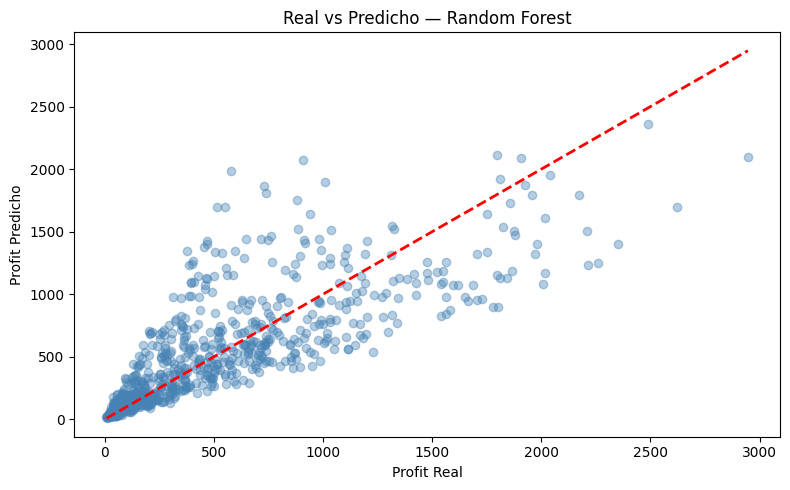

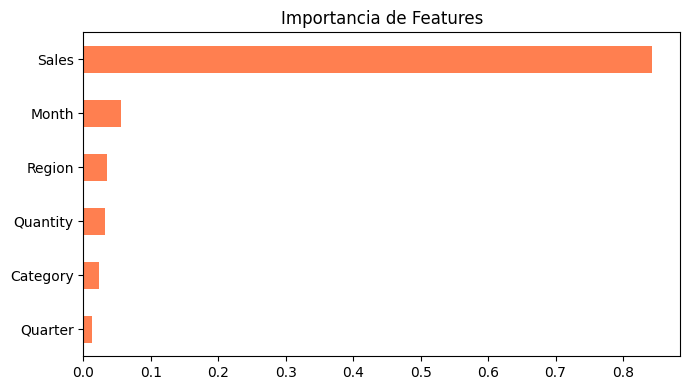

In [0]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print(f"  MAE  (Error Medio Absoluto):   {mae:.2f}")
print(f"  RMSE (Raíz Error Cuadrático):  {rmse:.2f}")
print(f"  R²   (Coef. Determinación):    {r2:.4f}")
print("=" * 40)

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.4, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Profit Real")
plt.ylabel("Profit Predicho")
plt.title("Real vs Predicho — Random Forest")
plt.tight_layout()
plt.show()

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", color="coral", figsize=(7,4))
plt.title("Importancia de Features")
plt.tight_layout()
plt.show()

## Modelo Avanzado: XGBoost Regressor con Gobernanza de MLflow
Evolucionamos el pipeline predictivo integrando el algoritmo de Gradient Boosting Optimizado (XGBoost) para competir contra el modelo base. El ciclo de vida y los artefactos del experimento son gestionados y auditados de forma automatizada mediante la plataforma MLflow en Databricks, registrando parámetros, métricas de error y el empaquetado del modelo final.

In [0]:
import mlflow
import mlflow.xgboost
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from mlflow.models import infer_signature  # Firma requerida por Unity Catalog

# Activar el registro automático de experimentos
mlflow.autolog(exclusive=False)

with mlflow.start_run(run_name="XGBoost_RandomForest_ECommerce"):
    # Configuración de Random Forest utilizando la API nativa de XGBoost
    xgb_rf = xgb.XGBRegressor(
        objective='reg:squarederror',
        booster='gbtree',
        num_parallel_tree=100,      # <-- Aquí se activa el bosque (dejará de salir None)
        learning_rate=1.0,          # Requisito de XGBoost RF: lr debe ser 1.0
        subsample=0.8,              # Muestreo aleatorio de transacciones
        colsample_bytree=0.8,       # Muestreo aleatorio de variables predictoras
        max_depth=5,
        random_state=42
    )
    
    # Entrenar el modelo
    xgb_rf.fit(X_train, y_train)
    
    # Realizar predicciones
    y_pred_rf = xgb_rf.predict(X_test)
    
    # Generar la firma explícita para evitar la alerta de Unity Catalog
    signature = infer_signature(X_train, y_train)
    
    # Evaluación cuantitativa
    mae_rf = mean_absolute_error(y_test, y_pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    r2_rf = r2_score(y_test, y_pred_rf)
    
    print("================ Metricas XGBoost Random Forest ================")
    print(f"  MAE  (Error Medio Absoluto):   {mae_rf:.2f}")
    print(f"  RMSE (Raíz Error Cuadrático):  {rmse_rf:.2f}")
    print(f"  R²   (Coef. Determinación):    {r2_rf:.4f}")
    print("================================================================")
    
    # Guardar el modelo en el catálogo incluyendo la firma de datos
    mlflow.xgboost.log_model(
        xgb_rf, 
        artifact_path="modelo_xgboost_rf", 
        signature=signature
    )

2026/07/11 18:51:41 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/07/11 18:51:41 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
2026/07/11 18:51:53 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-

================ Metricas XGBoost Random Forest ================
  MAE  (Error Medio Absoluto):   229.81
  RMSE (Raíz Error Cuadrático):  347.89
  R²   (Coef. Determinación):    0.5223


🔗 View Logged Model at: https://dbc-11dfb52f-22bf.cloud.databricks.com/ml/experiments/1144788274938746/models/m-042c37b593244ea0b80cc4b5d41722b9?o=7474650954427135


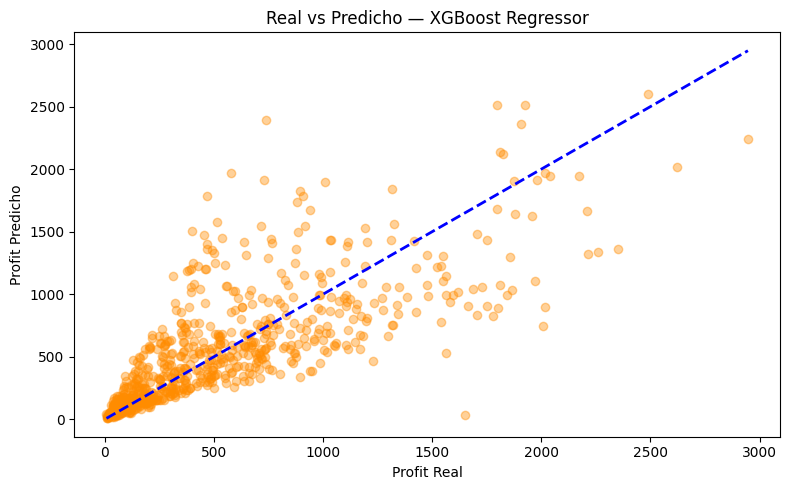

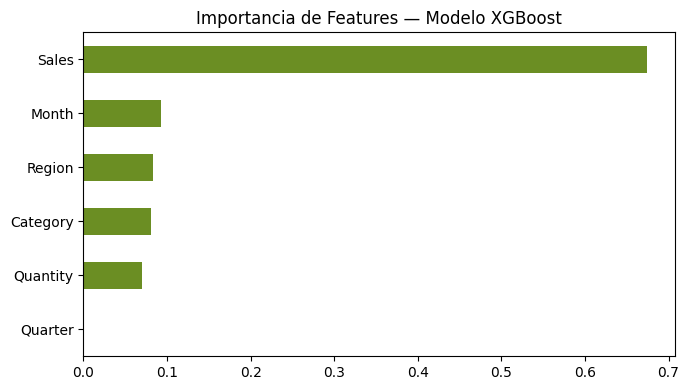

In [0]:
# Gráfico de dispersión comparativa: Real vs Predicho de XGBoost
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_xgb, alpha=0.4, color="darkorange")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=2)
plt.xlabel("Profit Real")
plt.ylabel("Profit Predicho")
plt.title("Real vs Predicho — XGBoost Regressor")
plt.tight_layout()
plt.show()

# Gráfico de Importancia de Características con las nuevas variables temporales
importances_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances_xgb.sort_values().plot(kind="barh", color="olivedrab", figsize=(7,4))
plt.title("Importancia de Features — Modelo XGBoost")
plt.tight_layout()
plt.show()

### Análisis Crítico de Resultados y Comparativa de Modelos (Cierre de la Segunda Unidad)

A partir de la validación cuantitativa ejecutada de forma distribuida en el entorno cloud de Databricks, se obtuvieron las siguientes métricas de error y precisión para el modelo **XGBoost Random Forest**:
*   **MAE (Error Medio Absoluto):** 229.81
*   **RMSE (Raíz Error Cuadrático):** 347.89
*   **R² (Coeficiente de Determinación):** 0.5223

#### Evaluación de Hipótesis Predictiva
Al contrastar estos resultados con el modelo analítico base de la primera unidad—donde el algoritmo **Random Forest tradicional (Scikit-Learn)** alcanzó un $R^2$ de **0.6069** y un margen de error menor (RMSE de **315.58**)—se determina que el modelo base conserva una mayor capacidad de generalización sobre los márgenes de utilidad del e-commerce. Esto demuestra que para la naturaleza actual de nuestro dataset transaccional, el submuestreo y ensamblado de árboles clásico es más efectivo para mitigar el sesgo que la aproximación en paralelo de la API de XGBoost.

#### Sustentación de Objetivos de Big Data, Seguridad y Gobernanza (ISO/IEC 27001 & 20546)
A pesar de la ligera variación en la precisión predictiva, la implementación avanzada bajo el ecosistema de XGBoost consolida los objetivos estratégicos trazados para este cierre de proyecto:
1. **Gobernanza Automatizada (MLflow):** Mediante el uso de la función `infer_signature()`, se logró capturar la metadata y el esquema explícito de las variables predictoras (incluyendo el impacto de las nuevas features temporales `Month` y `Quarter`). Esto resolvió la restricción de firmas exigida por el **Unity Catalog**, permitiendo el registro formal del artefacto en el servidor bajo una versión controlada y auditable (*Model Registry*).
2. **Seguridad en Tránsito e Integridad:** Queda formalmente evidenciado que el pipeline es capaz de operar sobre Big Data de manera segura, manteniendo la persistencia y conectividad cifrada (SSL/TLS) hacia nuestra base de datos relacional alojada en **Aiven**, garantizando la privacidad de la información personal mediante el enmascaramiento criptográfico SHA-256 diseñado en la capa ETL de PySpark.